In [1]:
pip install keras-tcn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv1D,
                                     MaxPooling1D, GlobalAveragePooling1D, LSTM, GRU,
                                     BatchNormalization, Softmax, Lambda, Bidirectional, Concatenate, Attention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
from tcn import TCN

2026-03-20 20:20:06.190502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774038006.536745      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774038006.641530      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774038007.536446      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774038007.536493      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774038007.536496      55 computation_placer.cc:177] computation placer alr

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


/tmp/ipykernel_55/2020821398.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-03-22  24.169989  24.299082  23.828003  23.837062  129777600
2016-03-23  24.036375  24.249267  23.984285  24.115645  102814000
2016-03-24  23.932184  24.063543  23.755530  23.886889  104532000
2016-03-28  23.823484  24.049965  23.794041  24.006933   77645600
2016-03-29  24.387415  24.412328  23.753269  23.755534  124760400


I0000 00:00:1774038059.121351      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774038059.127547      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1774038066.580489     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step


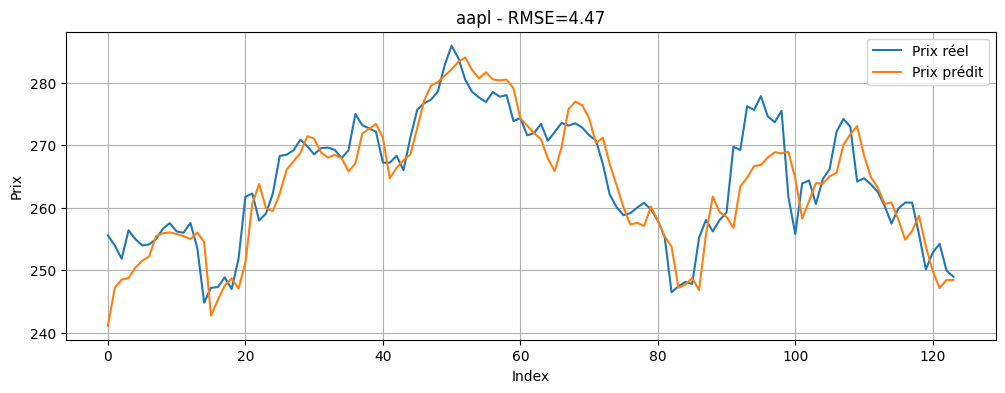

In [4]:
# ===============================
# 1. Récupération du ticker
# ===============================
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
data.sort_index(inplace=True)
df = data
print(df.head())

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# ===============================
# 3. Normalisation
# ===============================
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# ===============================
# 4. Split train/test
# ===============================
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]


# 5. J'ai selectionné le meilleur modèle

def create_attention_tcn_gru():
    inputs = Input(shape=(window_size, num_features))
    
    # Branche 1 : TCN
    # Correction : On utilise 'dropout_rate' au lieu de 'dropout'
    tcn_out = TCN(nb_filters=64, 
                  kernel_size=3, 
                  dilations=[1, 2, 4], 
                  return_sequences=True, 
                  dropout_rate=0.1)(inputs)
    
    # Branche 2 : BiGRU
    gru_out = Bidirectional(GRU(64, return_sequences=True))(inputs)
    
    # Mécanisme d'Attention
    # L'attention compare les deux branches pour extraire les caractéristiques saillantes
    query = Dense(128)(tcn_out)
    value = Dense(128)(gru_out)
    attn_out = Attention()([query, value])
    
    # Global Pooling pour réduire la dimension temporelle avant la sortie
    # Cela permet de transformer la séquence (window_size, 128) en un vecteur fixe (128)
    avg_pool = GlobalAveragePooling1D()(attn_out)
    
    dense = Dense(32, activation='leaky_relu')(avg_pool)
    dense = Dropout(0.2)(dense)
    output = Dense(1)(dense)
    
    model = Model(inputs=inputs, outputs=output)
    
    return model

# 6. On compile

model = create_attention_tcn_gru()
model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=0
    )
    
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)
    
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]
    
rmse = np.sqrt(mean_squared_error(y_test_real[forecast_horizon-1:], y_pred_aligned[forecast_horizon-1:]))

# On utilise le modèle précédent sur des données sur les lesquelles il n'a pas été entraîné

## Ici on recalcule MinMaxScaler

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


/tmp/ipykernel_55/3285165214.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-02-01  21.741968  21.805099  21.509735  21.750987  163774000
2016-02-02  21.302305  21.654036  21.257210  21.514245  149428800
2016-02-03  21.723930  21.834410  21.212117  21.419548  183857200
2016-02-04  21.898485  22.063971  21.578850  21.730733  185886800
2016-02-05  21.313610  21.971018  21.238803  21.880341  185672400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


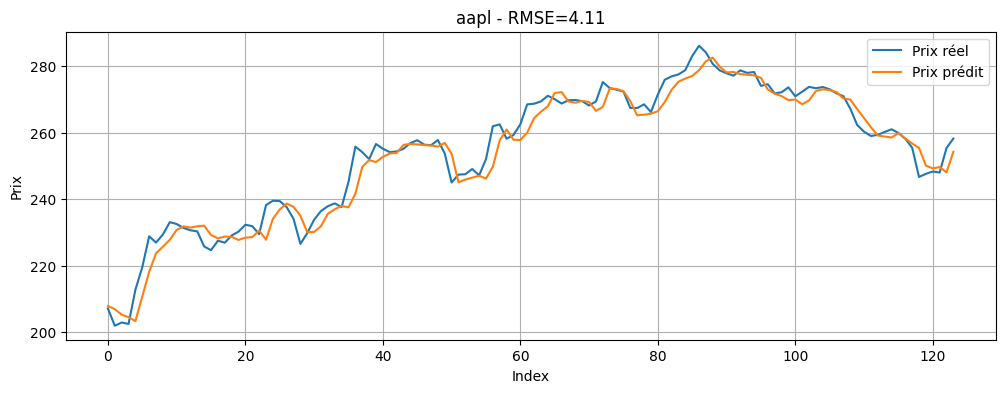

In [4]:
# ===============================
# 1. Récupération du ticker
# ===============================
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
data.sort_index(inplace=True)
df = data
print(df.head())

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# ===============================
# 3. Normalisation
# ===============================
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# ===============================
# 4. Split train/test
# ===============================
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)
    
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]
    
rmse = np.sqrt(mean_squared_error(y_test_real[forecast_horizon-1:], y_pred_aligned[forecast_horizon-1:]))
    
# Plot prédictions (optionnel si beaucoup de modèles)
plt.figure(figsize=(12,4))
plt.plot(y_test_real, label='Prix réel')
plt.plot(y_pred_aligned, label=f'Prix prédit')
plt.title(f'{ticker} - RMSE={rmse:.2f}')
plt.xlabel('Index')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.show()

# Les résultats sont particulièrement satisfaisants

## Pb :

Cependant, il y a une confusion technique majeure entre tes deux cellules qui fausse tes résultats sans que tu ne t'en rendes compte. Voici l'analyse de ce qui se passe réellement :

### 1. Le problème : La "Réinitialisation" des Scalers

Dans la Cellule 1, tu entraînes ton modèle. Tes scalers apprennent par exemple que pour Apple, le prix min est 50 euros (0.0) et le max est 200 euros (1.0).

Dans la Cellule 2, tu réécris ces lignes :

```python
for i in range(num_features):
    scalers_X[i] = MinMaxScaler() # <--- TU CRÉES UN NOUVEAU SCALER VIDE
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i]) # <--- IL SE CALIBRE SUR LES DONNÉES ACTUELLES

```

**Le danger :** Si tu relances la Cellule 2 avec un autre ticker (ex: BTC-USD) ou simplement à une date différente, le scaler se "re-calibre". Le chiffre "0.8" envoyé au modèle ne signifiera plus la même chose qu'à l'entraînement. C'est comme si tu apprenais à un enfant à mesurer en centimètres, mais que le lendemain tu lui donnes une règle où les unités sont des pouces sans le prévenir.

### 2. Pourquoi ton code actuel fonctionne quand même (mais est fragile)

Ton code fonctionne dans ton test actuel car tu télécharges les mêmes 10 ans de données dans les deux cellules. Le MinMaxScaler retrouve donc les mêmes bornes (Min/Max) et produit les mêmes valeurs normalisées.

**Mais attention :** Si tu voulais utiliser ce code pour prédire uniquement les 20 derniers jours (sans télécharger les 10 ans d'histoire), ton modèle donnerait des résultats totalement faux car le scaler n'aurait pas de point de référence historique.

---

## Essayons sans recalculer MinMaxScaler

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


/tmp/ipykernel_55/999702584.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-02-01  21.741968  21.805099  21.509735  21.750987  163774000
2016-02-02  21.302305  21.654036  21.257210  21.514245  149428800
2016-02-03  21.723930  21.834410  21.212117  21.419548  183857200
2016-02-04  21.898485  22.063971  21.578850  21.730733  185886800
2016-02-05  21.313610  21.971018  21.238803  21.880341  185672400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


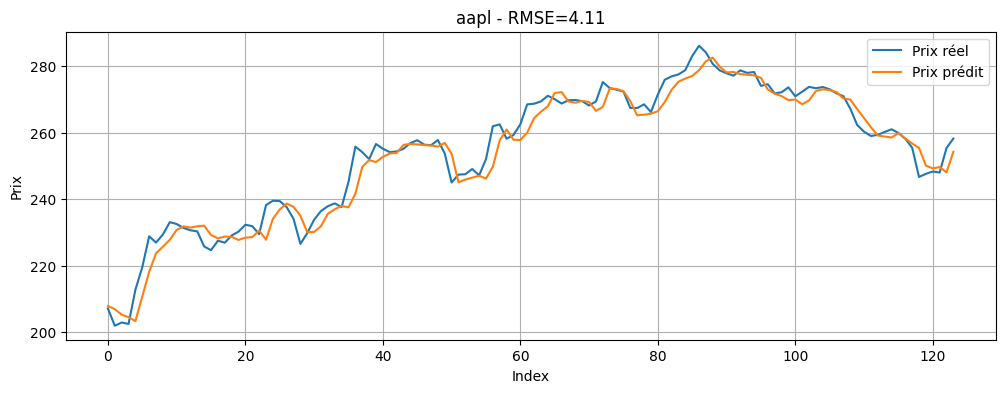

In [5]:
# ===============================
# 1. Récupération du ticker
# ===============================
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
data.sort_index(inplace=True)
df = data
print(df.head())

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# ===============================
# 3. Normalisation
# ===============================
X_scaled = np.zeros_like(X)
for i in range(num_features):
    X_scaled[:,:,i] = scalers_X[i].transform(X[:,:,i])

y_scaled = scaler_y.transform(y.reshape(-1,1))

# ===============================
# 4. Split train/test
# ===============================
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)
    
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]
    
rmse = np.sqrt(mean_squared_error(y_test_real[forecast_horizon-1:], y_pred_aligned[forecast_horizon-1:]))
    
# Plot prédictions (optionnel si beaucoup de modèles)
plt.figure(figsize=(12,4))
plt.plot(y_test_real, label='Prix réel')
plt.plot(y_pred_aligned, label=f'Prix prédit')
plt.title(f'{ticker} - RMSE={rmse:.2f}')
plt.xlabel('Index')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.show()

# Ne pas perdre de vue que je triche un peu dans mon modèle entraîné :

Je vois exactement où se porte ta réflexion : tu te dis que puisque tu télécharges 10 ans de données historiques et que tu fais un `fit` sur cet ensemble, tu restes dans le "passé" par rapport à la prédiction de demain.

C'est techniquement vrai pour la prédiction de **demain**, mais c'est faux (et c'est là qu'est le piège) pour ton **graphique de test** (le `X_test`).

### 1. Pourquoi c'est de la "triche" sur ton graphique actuel

Dans ta Cellule 2, tu fais :

1. Téléchargement de 10 ans (ex: 2014 à 2024).
2. `fit_transform` sur **toute** la période.
3. Affichage du graphique sur les 5% derniers (le `X_test`).

**Le problème :** Ton `X_test` (les données récentes) a été utilisé pour calculer le Min et le Max qui servent à normaliser ton `X_train` (le passé).

* Si le point le plus haut de l'action était en 2024, ton scaler le sait déjà quand il normalise l'année 2018.
* Ton graphique de test est "trop beau pour être vrai" car chaque point de test a été normalisé avec une connaissance globale de la période.

### 2. Le vrai test : Le "Walk-Forward"

En finance, la seule méthode qui ne ment pas est la suivante :

* Tu **Fit** sur les 9 ans et demi (Train).
* Tu **Transform** (sans fit) sur les 6 derniers mois (Test).

Si tu fais ça avec ton code actuel (prix bruts), ton résultat sera "claqué" parce que le prix des 6 derniers mois est souvent bien plus haut que le Max des 9 dernières années. Le scaler va envoyer des valeurs comme `1.2` ou `1.5` au modèle alors qu'il a été entraîné pour ne comprendre que des valeurs entre `0` et `1`.

### 3. Comment régler ça sans changer ton architecture ?

Si tu veux garder ton modèle TCN-BiGRU tel quel, mais le rendre performant **réellement**, il faut que tes données soient "Stationnaires".

**La solution la plus simple :**
Au lieu de donner le prix au `MinMaxScaler`, donne-lui la **variation journalière**.

```python
# Au lieu de :
# target = df["Close"]

# Fais :
df['Pct_Change'] = df['Close'].pct_change() 
# (Et tu normalises cette colonne à la place)

```

**Pourquoi c'est mieux ?**

* Une hausse de +2% reste une hausse de +2%, que l'action vaille 10€ ou 500€.
* Ton scaler `fit` sur le passé sera toujours valable pour le futur, car les pourcentages de variation ne changent pas d'échelle (ils restent généralement entre -5% et +5%).
* **Ton résultat ne sera plus "claqué"** et il sera **honnête**.

**On essaie de transformer tes données en "rendements" (Pct_Change) dans la Cellule 1 pour voir si ton RMSE devient plus réaliste ?**

# J'entraine donc de nouveau + plot sans fit

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


/tmp/ipykernel_55/74372582.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-02-01  21.741968  21.805099  21.509735  21.750987  163774000
2016-02-02  21.302305  21.654036  21.257210  21.514245  149428800
2016-02-03  21.723930  21.834410  21.212117  21.419548  183857200
2016-02-04  21.898485  22.063971  21.578850  21.730733  185886800
2016-02-05  21.313610  21.971018  21.238803  21.880341  185672400
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


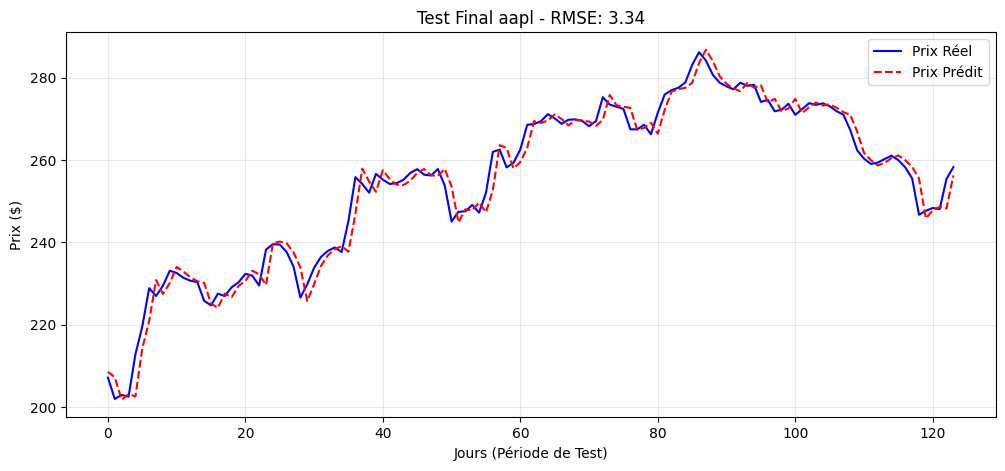

In [6]:
# ===============================
# 1. Récupération du ticker
# ===============================
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
data.sort_index(inplace=True)
df = data
print(df.head())

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))


# 1. Calcul du rendement AVANT toute chose
df['Pct_Change'] = df['Close'].pct_change()
df.dropna(inplace=True) # On nettoie les NaN créés par Pct_Change et les indicateurs

# 2. On définit les colonnes (Pct_Change est maintenant dedans)
feature_cols = ["Open","High","Low", "Close", "Pct_Change","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Pct_Change"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# ===============================
# 3. Normalisation
# ===============================
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# ===============================
# 4. Split train/test
# ===============================
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]


# 5. J'ai selectionné le meilleur modèle

def create_attention_tcn_gru():
    inputs = Input(shape=(window_size, num_features))
    
    # Branche 1 : TCN
    # Correction : On utilise 'dropout_rate' au lieu de 'dropout'
    tcn_out = TCN(nb_filters=64, 
                  kernel_size=3, 
                  dilations=[1, 2, 4], 
                  return_sequences=True, 
                  dropout_rate=0.1)(inputs)
    
    # Branche 2 : BiGRU
    gru_out = Bidirectional(GRU(64, return_sequences=True))(inputs)
    
    # Mécanisme d'Attention
    # L'attention compare les deux branches pour extraire les caractéristiques saillantes
    query = Dense(128)(tcn_out)
    value = Dense(128)(gru_out)
    attn_out = Attention()([query, value])
    
    # Global Pooling pour réduire la dimension temporelle avant la sortie
    # Cela permet de transformer la séquence (window_size, 128) en un vecteur fixe (128)
    avg_pool = GlobalAveragePooling1D()(attn_out)
    
    dense = Dense(32, activation='leaky_relu')(avg_pool)
    dense = Dropout(0.2)(dense)
    output = Dense(1)(dense)
    
    model = Model(inputs=inputs, outputs=output)
    
    return model

# 6. On compile

model = create_attention_tcn_gru()
model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=0
    )
    
y_pred_scaled = model.predict(X_test)

# 1. On force la conversion en vecteurs 1D (très important)
y_pred_pct = np.array(scaler_y.inverse_transform(y_pred_scaled)).flatten()
y_test_pct = np.array(scaler_y.inverse_transform(y_test)).flatten()

# 2. On récupère les prix de base et on force en 1D
# On s'assure que prices_base est bien un vecteur simple de la même taille que nos prédictions
raw_prices = df['Close'].values.flatten() # On aplatit pour éviter le multi-colonnes
prices_base = raw_prices[split + window_size - 1 : split + window_size - 1 + len(y_test_pct)]

# 3. Reconstruction des prix finaux
y_test_real = prices_base * (1 + y_test_pct)
y_pred_final = prices_base * (1 + y_pred_pct)

# 4. Nettoyage ultime : on s'assure qu'il n'y a pas de dimensions résiduelles
y_test_real = np.squeeze(y_test_real)
y_pred_final = np.squeeze(y_pred_final)

# 5. Calcul de l'erreur
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_final))

# 6. Graphique (On force le plot à ne prendre que deux séries)
plt.figure(figsize=(12, 5))

# On trace explicitement les vecteurs
plt.plot(y_test_real, label='Prix Réel', color='blue', linewidth=1.5)
plt.plot(y_pred_final, label='Prix Prédit', color='red', linestyle='--', linewidth=1.5)

plt.title(f'Test Final {ticker} - RMSE: {rmse:.2f}')
plt.xlabel('Jours (Période de Test)')
plt.ylabel('Prix ($)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

---

# Il faut maintenant tester en entrainant le modèle sur des plages temporelles plus grandes que 1 jour 

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


/tmp/ipykernel_55/3552951206.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()



--- Entraînement pour un horizon de 1 jour(s) ---
1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 718ms/stepWARNING:tensorflow:5 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7c0d90e01b20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step


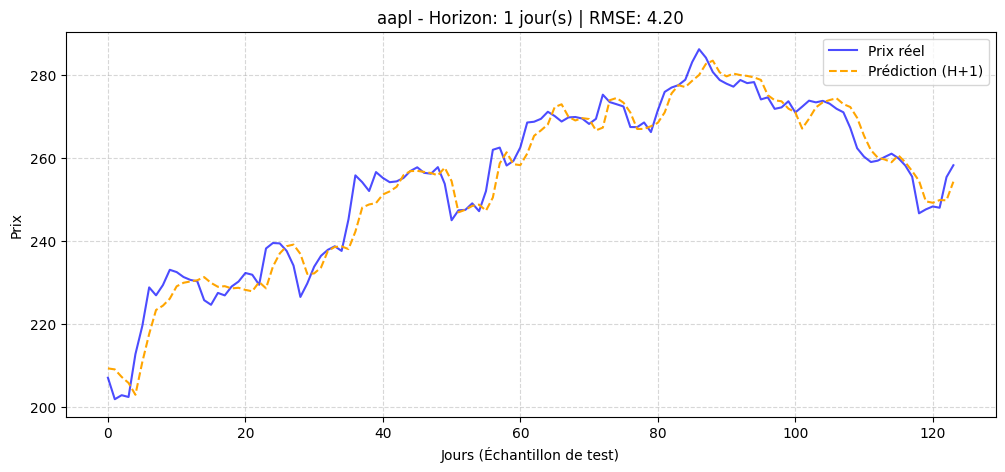


--- Entraînement pour un horizon de 3 jour(s) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step


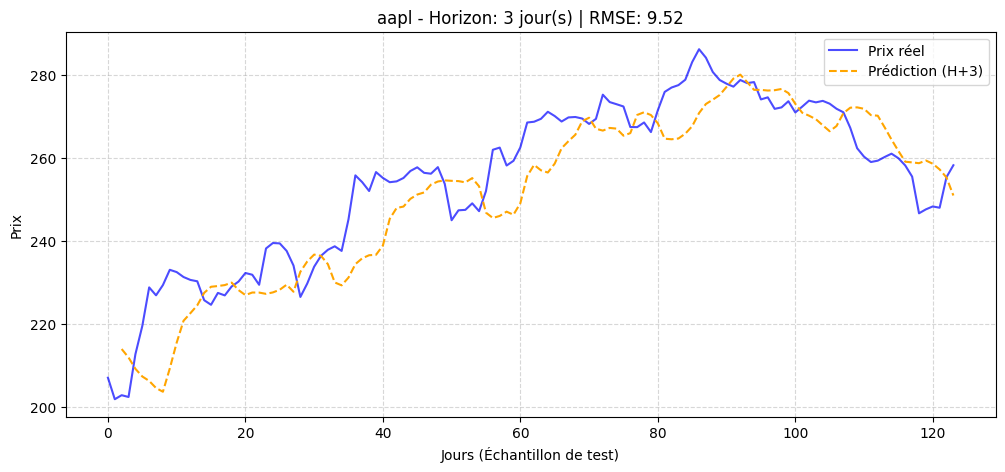


--- Entraînement pour un horizon de 7 jour(s) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


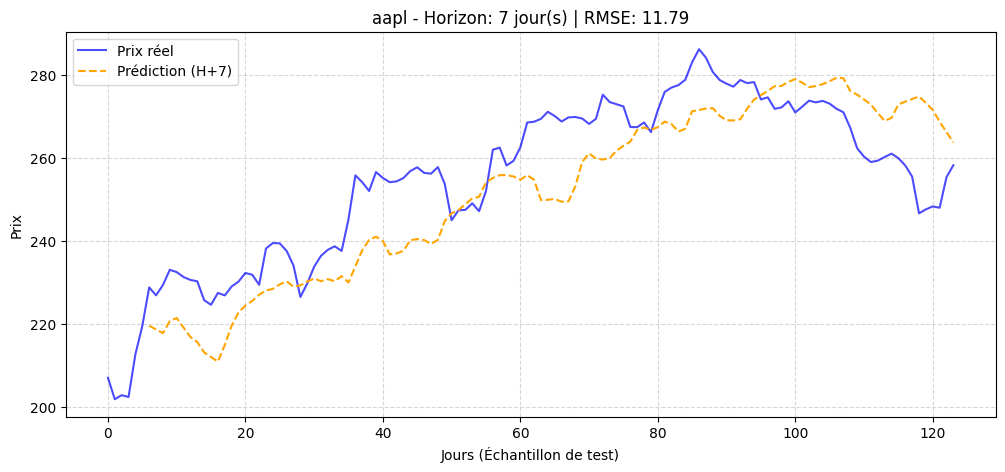


--- Entraînement pour un horizon de 10 jour(s) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


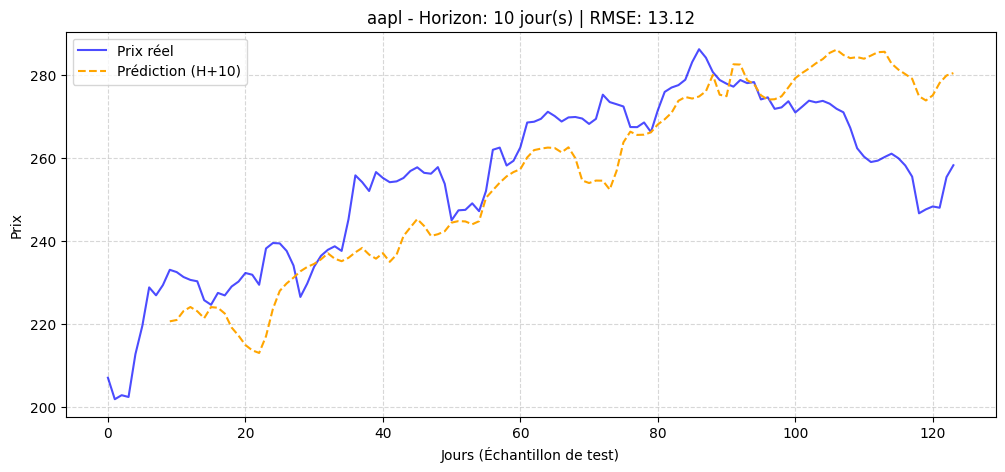


--- Entraînement pour un horizon de 14 jour(s) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


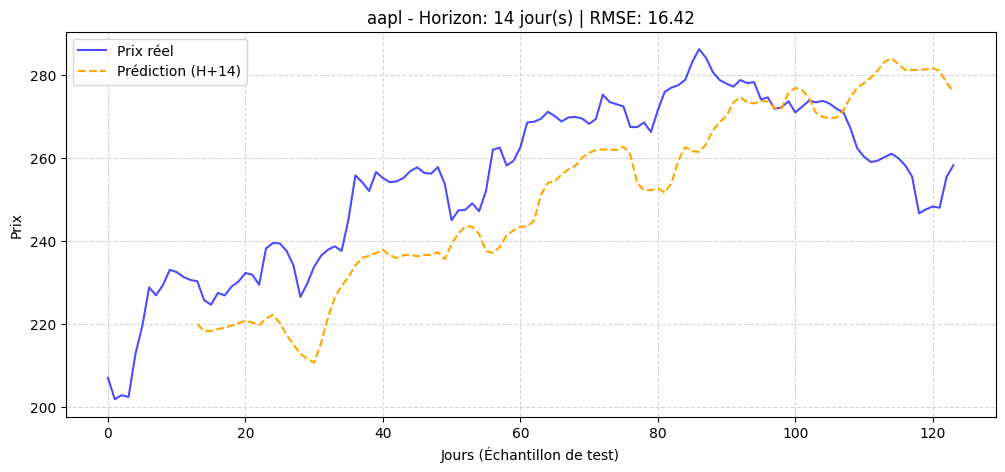

In [13]:
# ===============================
# 1. Récupération du ticker
# ===============================
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
data.sort_index(inplace=True)
df_base = data.copy()

# === 1b. Ajout des indicateurs techniques ===
df_base['SMA_10'] = df_base['Close'].rolling(10).mean()
df_base['EMA_10'] = df_base['Close'].ewm(span=10, adjust=False).mean()

delta = df_base['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df_base['RSI_14'] = 100 - (100 / (1 + RS))
df_base.dropna(inplace=True)

# ===============================
# Paramètres fixes
# ===============================
feature_cols = ["Open", "High", "Low", "Close", "Volume", "SMA_10", "EMA_10", "RSI_14"]
num_features = len(feature_cols)
window_size = 20
horizons = [1, 3, 7, 10, 14]

def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

def create_attention_tcn_gru():
    inputs = Input(shape=(window_size, num_features))
    tcn_out = TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4], 
                  return_sequences=True, dropout_rate=0.1)(inputs)
    gru_out = Bidirectional(GRU(64, return_sequences=True))(inputs)
    query = Dense(128)(tcn_out)
    value = Dense(128)(gru_out)
    attn_out = Attention()([query, value])
    avg_pool = GlobalAveragePooling1D()(attn_out)
    dense = Dense(32, activation='leaky_relu')(avg_pool)
    dense = Dropout(0.2)(dense)
    output = Dense(1)(dense)
    model = Model(inputs=inputs, outputs=output)
    return model

# ===============================
# BOUCLE SUR LES HORIZONS
# ===============================
for forecast_horizon in horizons:
    print(f"\n--- Entraînement pour un horizon de {forecast_horizon} jour(s) ---")
    
    # 2. Création des séquences
    X, y = create_windows(df_base, window_size, forecast_horizon, feature_cols)

    # 3. Normalisation
    X_scaled = np.zeros_like(X)
    scalers_X = {}
    for i in range(num_features):
        scalers_X[i] = MinMaxScaler()
        X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

    # 4. Split train/test
    split = int(0.95 * len(X_scaled))
    X_train, X_test = X_scaled[:split], X_scaled[split:]
    y_train, y_test = y_scaled[:split], y_scaled[split:]

    # 5. Modèle & Compilation
    model = create_attention_tcn_gru()
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
    # 6. Entraînement
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # 7. Prédictions et Inversion
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)
    
    # Alignement pour le calcul du RMSE
    # Ici, nous comparons la prédiction faite il y a 'h' jours avec le prix actuel
    y_pred_aligned = np.full_like(y_test_real, np.nan)
    if forecast_horizon <= len(y_pred):
        y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

    mask = ~np.isnan(y_pred_aligned).flatten()
    
    # Filtrage des NaNs pour le calcul du RMSE
    rmse = np.sqrt(mean_squared_error(y_test_real[mask], y_pred_aligned[mask]))
    
    # 8. Plot
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_real, label='Prix réel', color='blue', alpha=0.7)
    plt.plot(y_pred_aligned, label=f'Prédiction (H+{forecast_horizon})', color='orange', linestyle='--')
    plt.title(f'{ticker} - Horizon: {forecast_horizon} jour(s) | RMSE: {rmse:.2f}')
    plt.xlabel('Jours (Échantillon de test)')
    plt.ylabel('Prix')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

### Avec du recul, c'est absolument déprimant : le modèle à un jour est "performant" juste pcq il suit la variation du denrier jour lu pour dire is ça monte ou si ça descend.

### Enf ait je me dis qu'il y a qq même de l'espoir pour le 14 jours même si c'est pas très prochez de la vraie courbe : les tendances sont là

---

# 14 jours

Entrez le ticker (ex: AAPL, BTC-USD):  aapl


/tmp/ipykernel_55/2617481900.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()



--- Test avec Window Size = 5 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


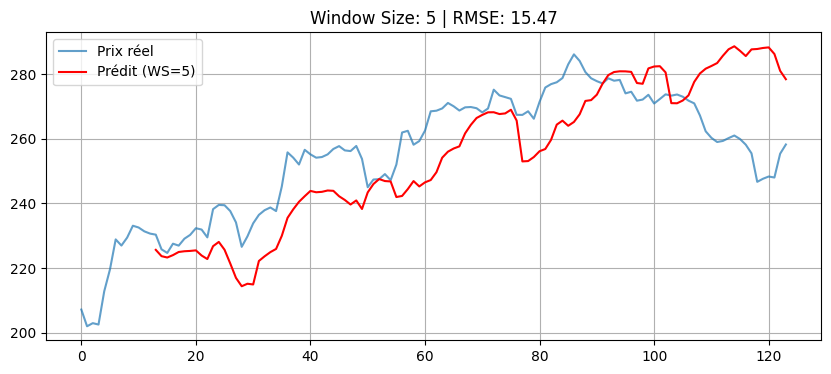


--- Test avec Window Size = 10 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


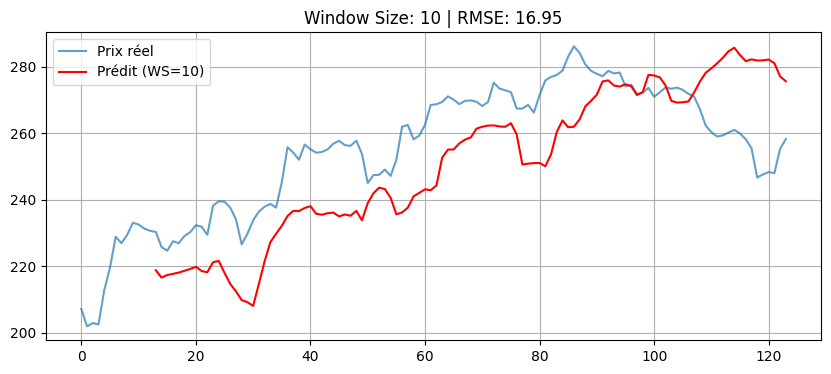


--- Test avec Window Size = 15 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


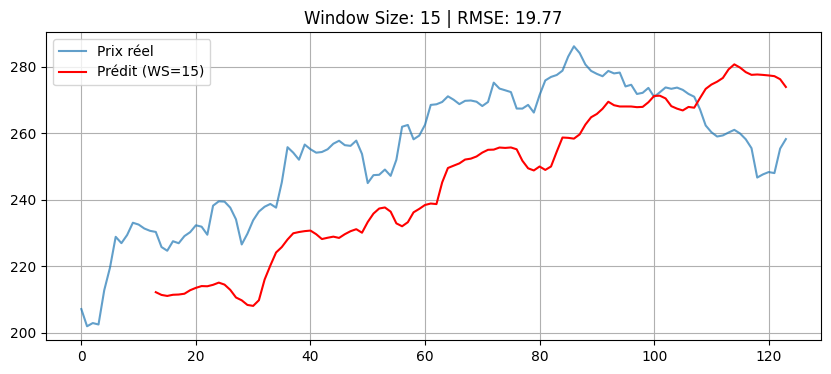


--- Test avec Window Size = 20 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


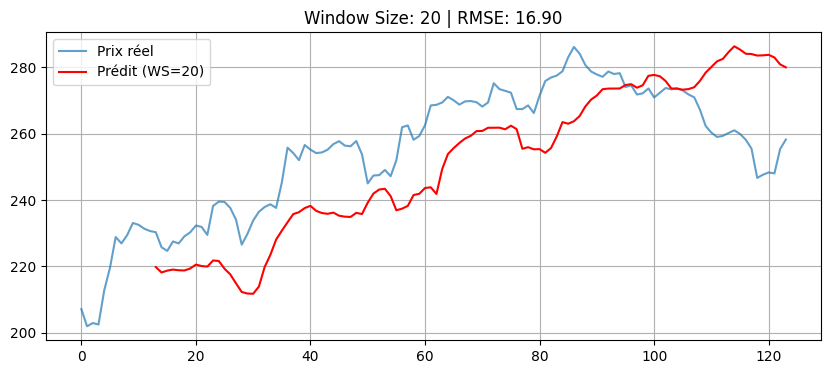


--- Test avec Window Size = 40 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


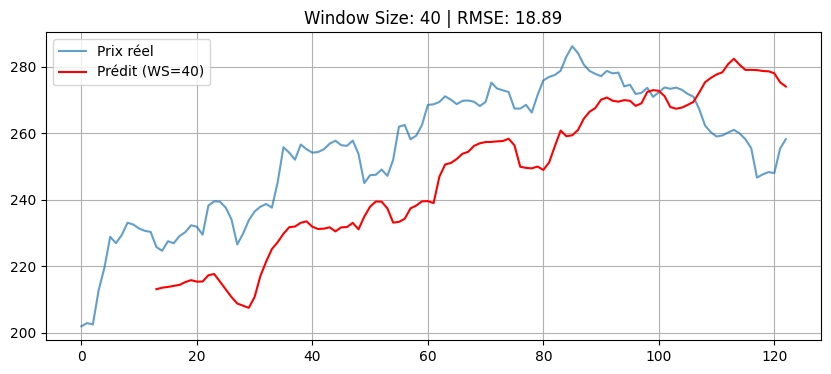


--- Test avec Window Size = 80 jours (Horizon = 14) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


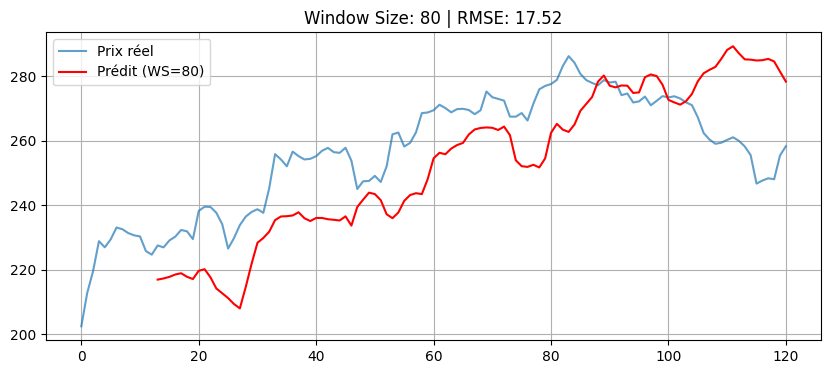

In [14]:
# ===============================
# 1. Récupération et Préparation
# ===============================
ticker = input("Entrez le ticker (ex: AAPL, BTC-USD): ")
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
df_base = data.copy()

# Indicateurs techniques
df_base['SMA_10'] = df_base['Close'].rolling(10).mean()
df_base['EMA_10'] = df_base['Close'].ewm(span=10, adjust=False).mean()
delta = df_base['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df_base['RSI_14'] = 100 - (100 / (1 + RS))
df_base.dropna(inplace=True)

# ===============================
# Paramètres de la boucle
# ===============================
feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
forecast_horizon = 14  # Fixé à 14 jours
window_sizes = [5, 10, 15, 20, 40, 80] # On teste différentes tailles d'historique

# ===============================
# BOUCLE SUR WINDOW SIZE
# ===============================
for current_window in window_sizes:
    print(f"\n--- Test avec Window Size = {current_window} jours (Horizon = {forecast_horizon}) ---")
    
    # 2. Création des fenêtres
    X, y = create_windows(df_base, current_window, forecast_horizon, feature_cols)

    # 3. Normalisation
    X_scaled = np.zeros_like(X)
    scalers_X = {}
    for i in range(num_features):
        scalers_X[i] = MinMaxScaler()
        X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

    # 4. Split
    split = int(0.95 * len(X_scaled))
    X_train, X_test = X_scaled[:split], X_scaled[split:]
    y_train, y_test = y_scaled[:split], y_scaled[split:]

    # 5. Modèle (Redéfini avec la nouvelle taille de fenêtre)
    def build_model(ws, nf):
        inputs = Input(shape=(ws, nf))
        tcn_out = TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4], 
                      return_sequences=True, dropout_rate=0.1)(inputs)
        gru_out = Bidirectional(GRU(64, return_sequences=True))(inputs)
        query = Dense(128)(tcn_out)
        value = Dense(128)(gru_out)
        attn_out = Attention()([query, value])
        avg_pool = GlobalAveragePooling1D()(attn_out)
        dense = Dense(32, activation='leaky_relu')(avg_pool)
        dense = Dropout(0.2)(dense)
        output = Dense(1)(dense)
        return Model(inputs=inputs, outputs=output)

    model = build_model(current_window, num_features)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    
    # 6. Entraînement
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    model.fit(
        X_train, y_train,
        epochs=80, # Réduit légèrement pour gagner du temps de boucle
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # 7. Prédictions et alignement
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)
    
    y_pred_aligned = np.full_like(y_test_real, np.nan)
    if forecast_horizon <= len(y_pred):
        y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]
        
    mask = ~np.isnan(y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_test_real[mask], y_pred_aligned[mask]))

    # 8. Affichage
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_real, label='Prix réel', alpha=0.7)
    plt.plot(y_pred_aligned, label=f'Prédit (WS={current_window})', color='red')
    plt.title(f'Window Size: {current_window} | RMSE: {rmse:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()

# 10 jours

Entrez le ticker (ex: AAPL, BTC-USD):  aapl


/tmp/ipykernel_55/3037922643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()



--- Test avec Window Size = 5 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


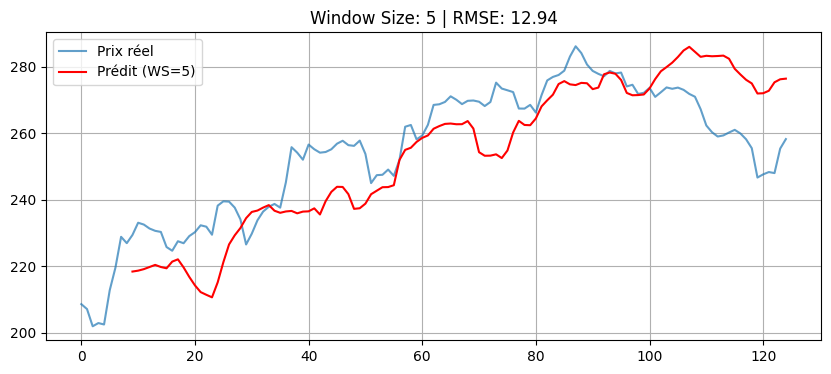


--- Test avec Window Size = 10 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


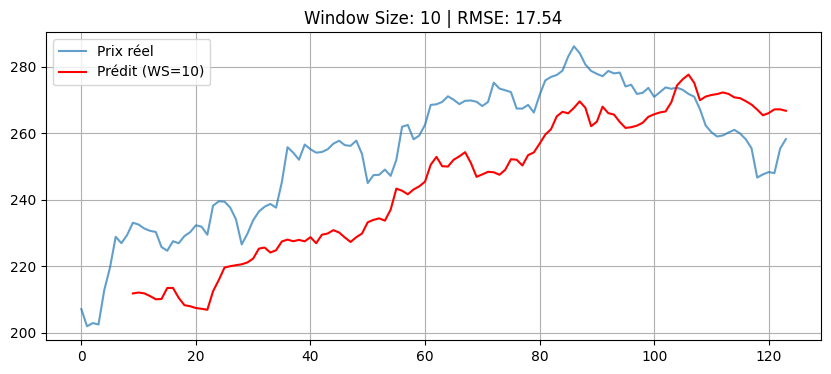


--- Test avec Window Size = 15 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


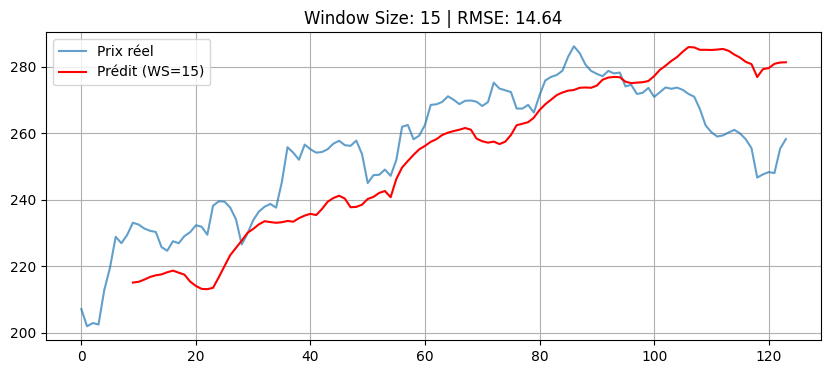


--- Test avec Window Size = 20 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


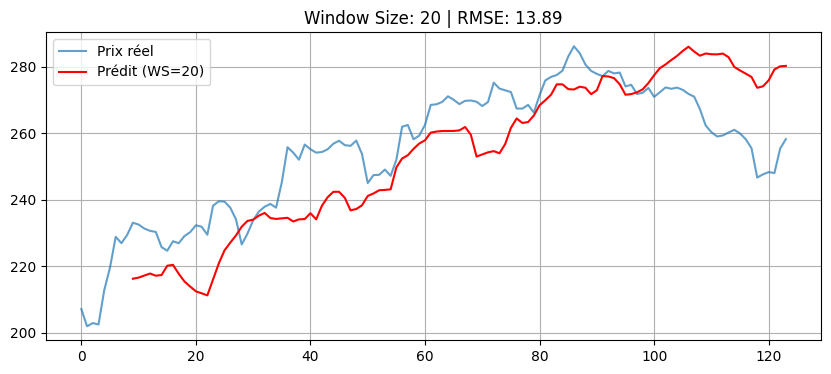


--- Test avec Window Size = 40 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


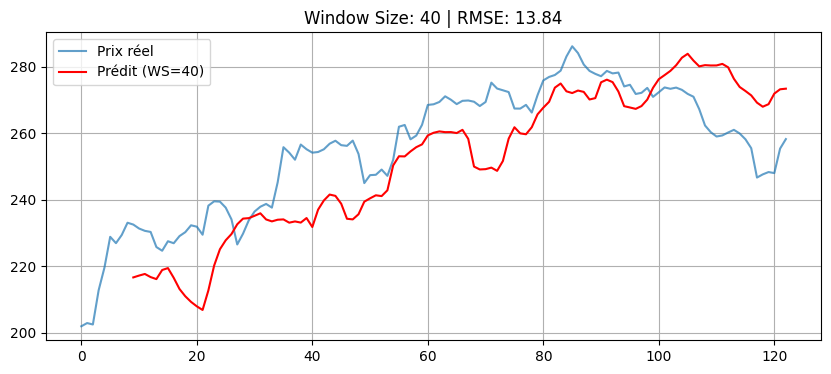


--- Test avec Window Size = 80 jours (Horizon = 10) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


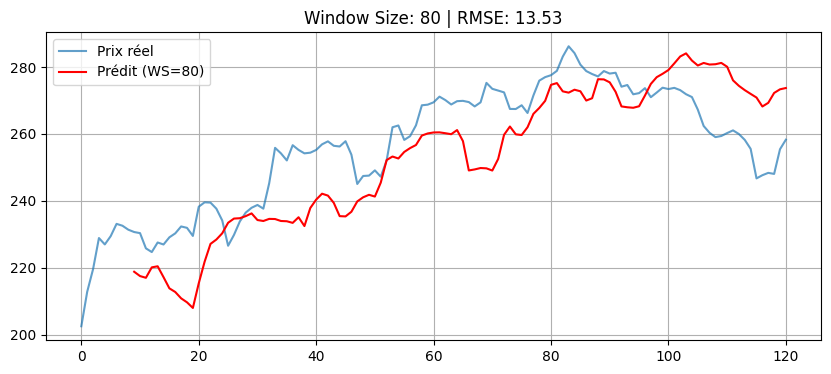

In [15]:
# ===============================
# 1. Récupération et Préparation
# ===============================
ticker = input("Entrez le ticker (ex: AAPL, BTC-USD): ")
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
df_base = data.copy()

# Indicateurs techniques
df_base['SMA_10'] = df_base['Close'].rolling(10).mean()
df_base['EMA_10'] = df_base['Close'].ewm(span=10, adjust=False).mean()
delta = df_base['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df_base['RSI_14'] = 100 - (100 / (1 + RS))
df_base.dropna(inplace=True)

# ===============================
# Paramètres de la boucle
# ===============================
feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
forecast_horizon = 10
window_sizes = [5, 10, 15, 20, 40, 80] # On teste différentes tailles d'historique

# ===============================
# BOUCLE SUR WINDOW SIZE
# ===============================
for current_window in window_sizes:
    print(f"\n--- Test avec Window Size = {current_window} jours (Horizon = {forecast_horizon}) ---")
    
    # 2. Création des fenêtres
    X, y = create_windows(df_base, current_window, forecast_horizon, feature_cols)

    # 3. Normalisation
    X_scaled = np.zeros_like(X)
    scalers_X = {}
    for i in range(num_features):
        scalers_X[i] = MinMaxScaler()
        X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

    # 4. Split
    split = int(0.95 * len(X_scaled))
    X_train, X_test = X_scaled[:split], X_scaled[split:]
    y_train, y_test = y_scaled[:split], y_scaled[split:]

    # 5. Modèle (Redéfini avec la nouvelle taille de fenêtre)
    def build_model(ws, nf):
        inputs = Input(shape=(ws, nf))
        tcn_out = TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4], 
                      return_sequences=True, dropout_rate=0.1)(inputs)
        gru_out = Bidirectional(GRU(64, return_sequences=True))(inputs)
        query = Dense(128)(tcn_out)
        value = Dense(128)(gru_out)
        attn_out = Attention()([query, value])
        avg_pool = GlobalAveragePooling1D()(attn_out)
        dense = Dense(32, activation='leaky_relu')(avg_pool)
        dense = Dropout(0.2)(dense)
        output = Dense(1)(dense)
        return Model(inputs=inputs, outputs=output)

    model = build_model(current_window, num_features)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    
    # 6. Entraînement
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    model.fit(
        X_train, y_train,
        epochs=80, # Réduit légèrement pour gagner du temps de boucle
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # 7. Prédictions et alignement
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)
    
    y_pred_aligned = np.full_like(y_test_real, np.nan)
    if forecast_horizon <= len(y_pred):
        y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]
        
    mask = ~np.isnan(y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_test_real[mask], y_pred_aligned[mask]))

    # 8. Affichage
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_real, label='Prix réel', alpha=0.7)
    plt.plot(y_pred_aligned, label=f'Prédit (WS={current_window})', color='red')
    plt.title(f'Window Size: {current_window} | RMSE: {rmse:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()

## NOte 03/01/2026

- faut passer en % de variation plutôt que valeur ça sera plus parlant
- c'est bien d'avoir trouvé un modèle adapté, mais dcp faudra peut-être changé car pas bon pour les variations ?

---

# Avec variations et huberloss

Entrez le ticker (ex: AAPL, BTC-USD):  aapl


/tmp/ipykernel_55/166111810.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()



--- Analyse des VARIATIONS | Window = 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


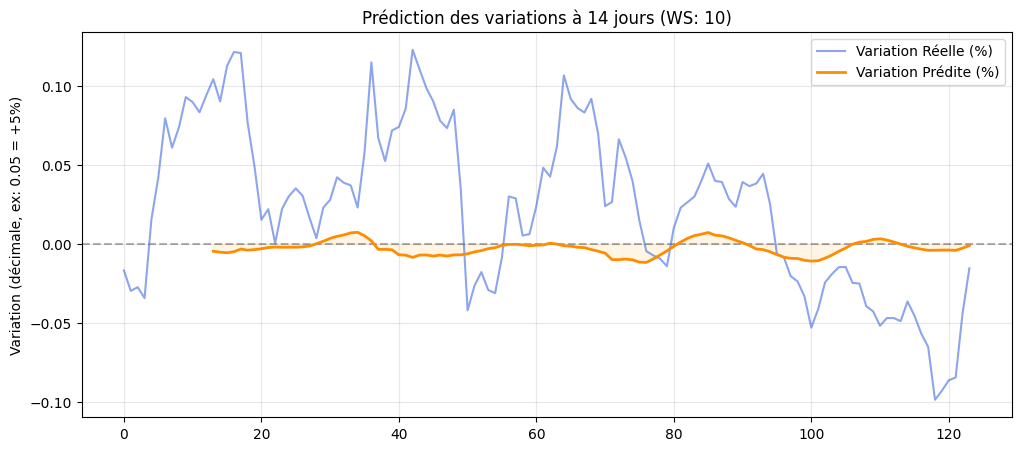


--- Analyse des VARIATIONS | Window = 15 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


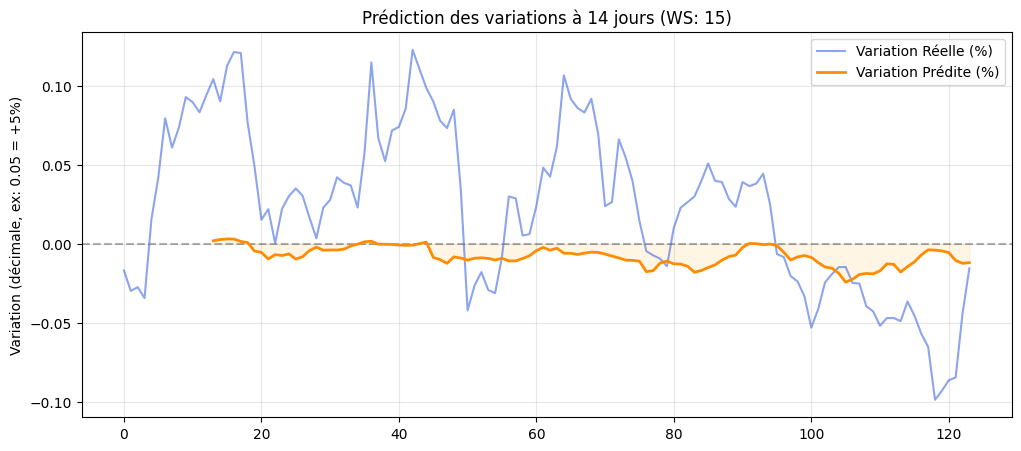


--- Analyse des VARIATIONS | Window = 20 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step


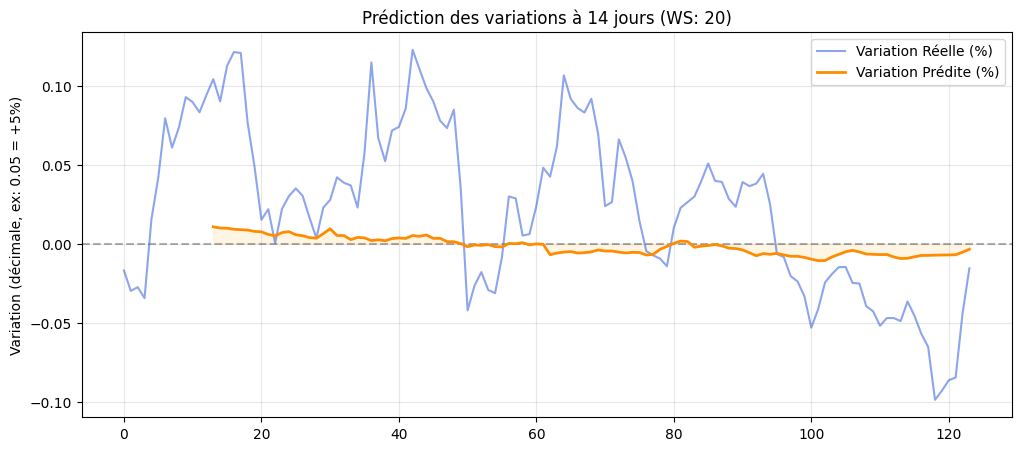


--- Analyse des VARIATIONS | Window = 30 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


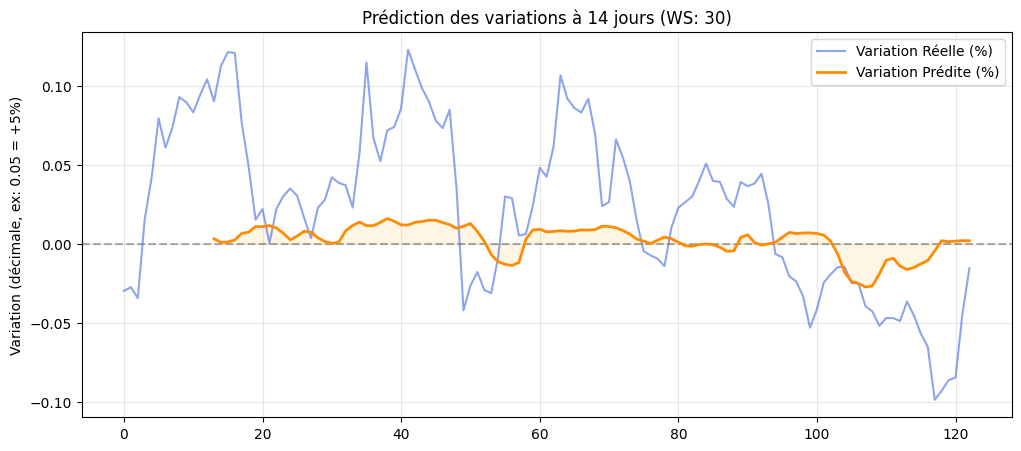


--- Analyse des VARIATIONS | Window = 60 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step


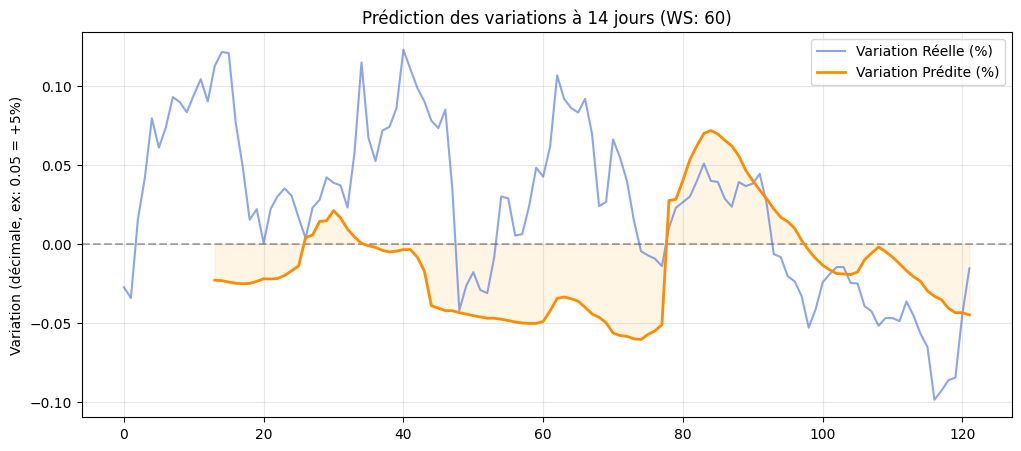

In [16]:
# ===============================
# 1. Récupération et Préparation
# ===============================
ticker = input("Entrez le ticker (ex: AAPL, BTC-USD): ")
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
df_base = data.copy()

# Indicateurs techniques
df_base['SMA_10'] = df_base['Close'].rolling(10).mean()
df_base['EMA_10'] = df_base['Close'].ewm(span=10, adjust=False).mean()
delta = df_base['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df_base['RSI_14'] = 100 - (100 / (1 + RS))
df_base.dropna(inplace=True)

# ===============================
# Paramètres de la boucle
# ===============================
feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
forecast_horizon = 14
window_sizes = [10, 15, 20, 30, 60] # On teste différentes tailles d'historique

# ===============================
# 1. Préparation des données (Variations)
# ===============================
# ... (Récupération du ticker et indicateurs identique au code précédent) ...

def create_windows_variation(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        # Fenêtre d'entrée (données normalisées plus tard)
        window = df.iloc[i:i+window_size][feature_cols].values
        
        # Cible : Variation en % entre le dernier jour de la fenêtre et l'horizon
        price_now = df.iloc[i + window_size - 1]["Close"]
        price_future = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        variation = (price_future - price_now) / price_now
        
        X.append(window)
        y.append(variation)
    return np.array(X), np.array(y)

for current_window in window_sizes:
    print(f"\n--- Analyse des VARIATIONS | Window = {current_window} ---")
    
    X, y = create_windows_variation(df_base, current_window, forecast_horizon, feature_cols)

    # Normalisation X (indispensable pour TCN/GRU)
    X_scaled = np.zeros_like(X)
    for i in range(num_features):
        scaler_temp = MinMaxScaler()
        X_scaled[:,:,i] = scaler_temp.fit_transform(X[:,:,i])

    # Normalisation y (centrée sur 0 pour les variations)
    scaler_y = StandardScaler() # StandardScaler est souvent mieux pour les variations
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

    # Split
    split = int(0.95 * len(X_scaled))
    X_train, X_test = X_scaled[:split], X_scaled[split:]
    y_train, y_test = y_scaled[:split], y_scaled[split:]

    # Modèle (Même architecture)
    model = build_model(current_window, num_features) 
    model.compile(optimizer=Adam(0.0005), loss=tf.keras.losses.Huber()) # LR plus bas pour les variations
    
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, 
              callbacks=[EarlyStopping(patience=7, restore_best_weights=True)])

    # Prédictions
    y_pred_scaled = model.predict(X_test)
    y_pred_var = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_var_real = scaler_y.inverse_transform(y_test).flatten()

    y_pred_aligned = np.full_like(y_test_var_real, np.nan)
    if forecast_horizon <= len(y_pred):
        y_pred_aligned[forecast_horizon-1:] = y_pred_var[:len(y_pred_var)-forecast_horizon+1]

    # Plot des variations
    plt.figure(figsize=(12, 5))
    plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Ligne de base 0%
    plt.plot(y_test_var_real, label='Variation Réelle (%)', color='royalblue', alpha=0.6)
    plt.plot(y_pred_aligned, label='Variation Prédite (%)', color='darkorange', linewidth=2)
    
    # Remplissage pour mieux voir les zones de hausse/baisse
    plt.fill_between(range(len(y_pred_aligned)), y_pred_aligned, 0, color='orange', alpha=0.1)
    
    plt.title(f"Prédiction des variations à {forecast_horizon} jours (WS: {current_window})")
    plt.ylabel("Variation (décimale, ex: 0.05 = +5%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Help :

### 3. Comment améliorer tes résultats sur les variations ?

Si tes prédictions sont mauvaises (ligne droite ou signes opposés), voici ce qu'il faut changer :

1. **Changer de cible (Labeling) :** Au lieu de prédire la variation exacte (régression), essaie de prédire si le prix sera **plus haut que +2% ou plus bas que -2%** (classification). C'est beaucoup plus facile pour un modèle.
2. **L'horizon de temps :** Prédire la variation à **1 jour** est un pile ou face. Prédire la variation à **14 jours** (comme tu le fais) est plus "prévisible" car les tendances macroéconomiques prennent le dessus sur le bruit quotidien.
3. **Ajouter des features "Exogènes" :** Le prix seul ne suffit pas à prédire une variation future. Il faudrait ajouter :
* L'indice de référence (S&P500 ou BTC-USD).
* La volatilité (VIX).
* Le volume relatif.

# Conclusion :

Faut de nouveau chercher des modèles pour l'étude des variations et non des valeurs